# 在 Colab 中打开
<a target="_blank" href="https://colab.research.google.com/github/Nicolepcx/ai-agents-the-definitive-guide/blob/main/CH02/ch02_swarms.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# 关于这个 Notebook

这个 Notebook 演示如何使用 [LangGraph Multi-Agent Swarm library](https://github.com/langchain-ai/langgraph-swarm-py) 提供的 `create_swarm` 构建并编译一个 **multi-agent swarm（多智能体群）**。Swarm（群）是一种简单的 orchestration construct（编排结构）：多个智能体可以协作，其中一个智能体默认处于激活状态，其他智能体则可以在需要时接管任务。

## 它展示了什么

* **Agent collaboration（智能体协作）**：用 `research_assistant` 和 `writer_assistant` 两个智能体组成一个 swarm。
* **Default active agent（默认活跃智能体）**：由 `research_assistant` 发起对话。
* **Compilation step（编译步骤）**：调用 `.compile()` 把 swarm 固化为可执行 app/graph（应用/图），从而处理输入并在智能体之间路由。

## 它如何工作

1. **定义智能体**：代码中分别定义 `research_assistant` 和 `writer_assistant`，每个智能体都有自己的工具、Prompt 或角色。
2. **创建 swarm**：`create_swarm()` 接收这些智能体对象，构建协作结构。
3. **默认激活**：`default_active_agent="research_assistant"` 确保先启动研究；只有在需要时，控制权才转交 `writer_assistant`。
4. **编译**：`.compile()` 返回 runnable object（可运行对象，通常是 LangGraph app），负责跨智能体管理 state（状态）、routing（路由）和 message passing（消息传递）。

## 为什么采用这种模式

* 角色保持 **modular（模块化）**：每个智能体拥有独立的工具和职责。
* 提供明确的 **coordination（协调）**：swarm 负责管理智能体之间的轮换。
* 易于 **扩展**：可以增加编辑、审校、验证等智能体，而不必重写编排逻辑。

## 如何扩展与调整

* 增加 **validator agent（验证智能体）**，在写作智能体定稿前检查事实准确性。
* 如果希望先起草后研究，可以更改 **default active agent（默认活跃智能体）**。
* 增加 **routing rules（路由规则）** 或评分函数，决定下一步应该 hand off（移交）给哪个智能体。
* 使用 checkpointer（检查点保存器）持久化 swarm 状态，使多轮任务可以跨会话继续。

## 运行要求与说明

* 需要安装 `langgraph_swarm` 或等价工具。
* 传给 `create_swarm` 的智能体必须已经定义并绑定工具。
* Swarm 的行为取决于智能体 Prompt；清晰的角色定义通常能改善协作质量。

In [ ]:
!pip install -q \
    langchain==0.3.27 \
    langgraph==0.6.7 \
    langchain-openai==0.3.33 \
    langchain_experimental==0.3.4 \
    langchain_community==0.3.30 \
    langchain-tavily==0.2.11 \
    python-dotenv==1.1.1 \
    langchain-core \
    langgraph-swarm==0.0.14

# API Key 配置

In [ ]:
# 方案 1（推荐）：在项目目录中创建 `.env` 文件，并写入：
# OPENAI_API_KEY=your_openai_key_here
# TAVILY_API_KEY=your_tavily_key_here
#
# 方案 2：直接通过 Notebook magic 命令设置：
# %env OPENAI_API_KEY=your_openai_key_here
# %env TAVILY_API_KEY=your_tavily_key_here

from dotenv import load_dotenv
import os

# 如果存在 `.env`，则从中加载。
load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

# Fallback（回退方案）：如果仍缺少密钥，则交互式询问。
if not OPENAI_API_KEY:
    print("⚠️ OPENAI_API_KEY not found. You can set it with `%env` in the notebook or enter it below.")
    OPENAI_API_KEY = input("Enter your OPENAI_API_KEY: ").strip()

if not TAVILY_API_KEY:
    print("⚠️ TAVILY_API_KEY not found. You can set it with `%env` in the notebook or enter it below.")
    TAVILY_API_KEY = input("Enter your TAVILY_API_KEY: ").strip()

print("✅ API keys loaded successfully!")


# 导入依赖

In [ ]:
import os
from typing import Annotated, List
from dotenv import load_dotenv

from langchain_openai import ChatOpenAI
from langchain_core.tools import tool

from langchain_community.document_loaders import WebBaseLoader
from langchain_tavily import TavilySearch

from langgraph.prebuilt import create_react_agent
from langgraph_swarm import create_swarm, create_handoff_tool


# 工具

In [ ]:
# Tavily 网页搜索
tavily_tool = TavilySearch(max_results=5).as_tool()

@tool
def scrape_webpages(urls: List[str]) -> str:
    """Use requests and bs4 to scrape the provided web pages for detailed information."""
    loader = WebBaseLoader(urls)
    docs = loader.load()
    return "\n\n".join(
        [
            f'<Document name="{doc.metadata.get("title", "")}">\n{doc.page_content}\n</Document>'
            for doc in docs
        ]
    )


# Handoff tools（移交工具）

In [ ]:
to_writer = create_handoff_tool(
    agent_name="writer_assistant",
    description="Transfer to the writing assistant to synthesize sources into an answer.",
)
to_research = create_handoff_tool(
    agent_name="research_assistant",
    description="Return to the research assistant to fetch or scrape more sources.",
)

# LLM 配置

In [ ]:
# 通过 LangChain 使用 OpenAI；请在环境变量中设置 OPENAI_API_KEY。
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# Agents（智能体）

In [ ]:
research_assistant = create_react_agent(
    model=llm,
    tools=[tavily_tool, scrape_webpages, to_writer],
    prompt=(
        "You are a research assistant. Search the web with Tavily. "
        "When you have 3 to 5 solid sources, scrape key pages for details, "
        "then hand off to the writer assistant."
    ),
    name="research_assistant",
)

writer_assistant = create_react_agent(
    model=llm,
    tools=[to_research],
    prompt=(
        "You are a writing assistant. Read the provided Documents and messages. "
        "Synthesize a concise answer with citations by site name in brackets. "
        "If sources are thin or unclear, hand back to research with a short request."
    ),
    name="writer_assistant",
)

# Swarm（智能体群）

In [ ]:
swarm = create_swarm(
    agents=[research_assistant, writer_assistant],
    default_active_agent="research_assistant",
).compile()

# 运行

In [ ]:
user_request = {
    "messages": [
        {
            "role": "user",
            "content": (
                "Find the current Swiss fintech licensing options for small startups. "
                "Gather authoritative sources and produce a short summary with three bullet points and references."
            ),
        }
    ]
}

for chunk in swarm.stream(user_request):
    print(chunk)
    print()


/tmp/ipython-input-338926207.py:18: LangChainBetaWarning: This API is in beta and may change in the future.
  tavily_tool = TavilySearch(max_results=5).as_tool()


{'research_assistant': {'messages': [HumanMessage(content='Find the current Swiss fintech licensing options for small startups. Gather authoritative sources and produce a short summary with three bullet points and references.', additional_kwargs={}, response_metadata={}, id='92bc972f-39c4-40a1-9c1d-c08aafc59ce9'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_P7xJzxBNz9GBKxqRP13Tml9z', 'function': {'arguments': '{"query":"Swiss fintech licensing options for startups 2024","search_depth":"advanced"}', 'name': 'tavily_search'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_tokens': 2970, 'total_tokens': 2999, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_560af6e559', 'id': 'chatcmpl

In [ ]:
# Plot graph

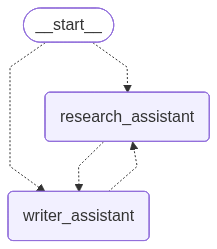

In [ ]:
from IPython.display import Image, display

display(Image(swarm.get_graph().draw_mermaid_png()))